# DATASET SACADO DE KAGGLE (https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores)

In [52]:
# Librerías
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

# Configurar visualización amplia 
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(300)
pl.Config.set_fmt_str_lengths(150)
pl.Config.set_tbl_rows(10)

polars.config.Config

### Cargamos el Dataset como LazyFrame

In [53]:
# Install dependencies as needed:
# pip install kagglehub[polars-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Games.csv"

# Load the latest version
lf = kagglehub.load_dataset(
  KaggleDatasetAdapter.POLARS,
  "eoinamoore/historical-nba-data-and-player-box-scores",
  file_path,
)

print("First 5 records:", lf.collect().head())

/tmp/ipykernel_720981/1854991282.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  lf = kagglehub.load_dataset(


First 5 records: shape: (5, 22)
┌──────────┬───────────────┬───────────────┬──────────────┬────────────┬──────────────┬──────────────┬────────────┬───────────┬───────────┬────────────┬──────────┬─────────────┬───────────┬──────────────┬──────────────┬────────────┬─────────┬──────────────┬──────────────┬────────────┬──────────────┐
│ gameId   ┆ gameDateTimeE ┆ hometeamCity  ┆ hometeamName ┆ hometeamId ┆ awayteamCity ┆ awayteamName ┆ awayteamId ┆ homeScore ┆ awayScore ┆ winner     ┆ gameType ┆ gameSubtype ┆ gameLabel ┆ gameSubLabel ┆ seriesGameNu ┆ attendance ┆ arenaId ┆ arenaName    ┆ arenaCity    ┆ arenaState ┆ officials    │
│ ---      ┆ st            ┆ ---           ┆ ---          ┆ ---        ┆ ---          ┆ ---          ┆ ---        ┆ ---       ┆ ---       ┆ ---        ┆ ---      ┆ ---         ┆ ---       ┆ ---          ┆ mber         ┆ ---        ┆ ---     ┆ ---          ┆ ---          ┆ ---        ┆ ---          │
│ i64      ┆ ---           ┆ str           ┆ str          ┆ i64  

### Analisis de Datos

In [54]:
# Visualizamos los datos con LazyFrame
lf.collect()

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameSubtype,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials
i64,str,str,str,i64,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,i64,str,str,str,str
22500882,"""2026-03-02 22:00:00""","""Golden State""","""Warriors""",1610612744,"""LA""","""Clippers""",1610612746,101,114,1610612746,"""Regular Season""","""""","""""","""""","""""",18064,1000011,"""Chase Center""","""San Francisco""","""CA""","""Sean Wright, Brett Nansel, Justin Van Duyne"""
22500881,"""2026-03-02 21:00:00""","""Utah""","""Jazz""",1610612762,"""Denver""","""Nuggets""",1610612743,125,128,1610612743,"""Regular Season""","""""","""""","""""","""""",18186,1000106,"""Delta Center""","""Salt Lake City""","""UT""","""Mitchell Ervin, Andy Nagy, Pat O'Connell"""
22500880,"""2026-03-02 19:30:00""","""Milwaukee""","""Bucks""",1610612749,"""Boston""","""Celtics""",1610612738,81,108,1610612738,"""Regular Season""","""""","""""","""""","""""",15992,642,"""Fiserv Forum""","""Milwaukee""","""WI""","""Pat Fraher, John Goble, Biniam Maru"""
22500879,"""2026-03-02 19:00:00""","""Washington""","""Wizards""",1610612764,"""Houston""","""Rockets""",1610612745,118,123,1610612745,"""Regular Season""","""""","""""","""""","""""",17352,77,"""Capital One Arena""","""Washington""","""DC""","""Tony Brothers, Marat Kogut, Jacyn Goble"""
22500878,"""2026-03-01 21:30:00""","""Los Angeles""","""Lakers""",1610612747,"""Sacramento""","""Kings""",1610612758,128,104,1610612747,"""Regular Season""","""""","""""","""""","""""",18272,1000069,"""Crypto.com Arena""","""Los Angeles""","""CA""","""Mitchell Ervin, Andy Nagy, Pat O'Connell"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
24600083,"""1946-12-08 19:00:00""","""New York""","""Knicks""",1610612752,"""Boston""","""Celtics""",1610612738,62,44,1610612752,"""Regular Season""",null,null,null,null,null,0,null,null,null,null
24600078,"""1946-12-07 19:00:00""","""Boston""","""Celtics""",1610612738,"""New York""","""Knicks""",1610612752,65,90,1610612752,"""Regular Season""",null,null,null,null,null,0,null,null,null,null
24600076,"""1946-12-05 19:00:00""","""Philadelphia""","""Warriors""",1610612744,"""New York""","""Knicks""",1610612752,62,51,1610612744,"""Regular Season""",null,null,null,null,null,0,null,null,null,null


In [55]:
lf.schema

/tmp/ipykernel_720981/2177650233.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  lf.schema


Schema([('gameId', Int64),
        ('gameDateTimeEst', String),
        ('hometeamCity', String),
        ('hometeamName', String),
        ('hometeamId', Int64),
        ('awayteamCity', String),
        ('awayteamName', String),
        ('awayteamId', Int64),
        ('homeScore', Int64),
        ('awayScore', Int64),
        ('winner', Int64),
        ('gameType', String),
        ('gameSubtype', String),
        ('gameLabel', String),
        ('gameSubLabel', String),
        ('seriesGameNumber', String),
        ('attendance', Int64),
        ('arenaId', Int64),
        ('arenaName', String),
        ('arenaCity', String),
        ('arenaState', String),
        ('officials', String)])

In [56]:
lf.describe()

statistic,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameSubtype,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials
str,f64,str,str,str,f64,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,f64,str,str,str,str
"""count""",72868.0,"""72868""","""72868""","""72868""",72868.0,"""72868""","""72868""",72868.0,72868.0,72868.0,72868.0,"""72868""","""252""","""4123""","""409""","""5916""",983.0,72868.0,"""989""","""989""","""980""","""989"""
"""null_count""",0.0,"""0""","""0""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""72616""","""68745""","""72459""","""66952""",71885.0,0.0,"""71879""","""71879""","""71888""","""71879"""
"""mean""",2.5778e7,null,null,null,1.6106e9,null,null,1.6105e9,105.978482,102.432412,1.6106e9,null,null,null,null,null,17855.223805,41158.539359,null,null,null,null
"""std""",6.4029e6,null,null,null,41.20088,null,null,1.4614e7,14.299934,13.954499,41.196307,null,null,null,null,null,1867.076176,198458.716477,null,null,null,null
"""min""",1.0300001e7,"""1946-11-26 19:00:00""","""""","""76ers""",1.6106e9,"""""","""76ers""",15016.0,0.0,0.0,1.6106e9,"""All-Star Game""","""""","""""","""""","""""",5993.0,0.0,"""Acrisure Arena""","""Abu Dhabi""","""AL""","""Aaron Smith, Jacyn Goble, Jenna Schroeder"""
"""25%""",2.130076e7,null,null,null,1.6106e9,null,null,1.6106e9,96.0,93.0,1.6106e9,null,null,null,null,null,17009.0,5.0,null,null,null,null
"""50%""",2.6200098e7,null,null,null,1.6106e9,null,null,1.6106e9,106.0,102.0,1.6106e9,null,null,null,null,null,18094.0,44.0,null,null,null,null
"""75%""",2.8700356e7,null,null,null,1.6106e9,null,null,1.6106e9,115.0,112.0,1.6106e9,null,null,null,null,null,19156.0,136.0,null,null,null,null
"""max""",6.2500001e7,"""2026-03-02 22:00:00""","""Washington""","""Zephyrs""",1.6106e9,"""Washington""","""Zephyrs""",1.6106e9,184.0,186.0,1.6106e9,"""Regular Season""","""in-season-knockout""","""West Play-In""","""West Semifinal""","""7.0""",22093.0,1.000159e6,"""Xfinity Mobile Arena""","""Washington""","""WI""","""Zach Zarba, Tyler Ricks, Brandon Schwab"""


In [57]:
lf.null_count().collect()

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameSubtype,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,72616,68745,72459,66952,71885,0,71879,71879,71888,71879


In [58]:
# Filtrar filas con al menos un nulo
filas_con_nulos = lf.filter(
    pl.any_horizontal(pl.all().is_null())
)

# Ejecutar y ver resultado (primeras 10 filas, por ejemplo)
print(filas_con_nulos.collect())

shape: (72_693, 22)
┌──────────┬──────────────┬──────────────┬──────────────┬────────────┬──────────────┬──────────────┬────────────┬───────────┬───────────┬────────────┬──────────┬─────────────┬──────────────┬──────────────┬──────────────┬────────────┬─────────┬──────────────┬─────────────┬────────────┬──────────────┐
│ gameId   ┆ gameDateTime ┆ hometeamCity ┆ hometeamName ┆ hometeamId ┆ awayteamCity ┆ awayteamName ┆ awayteamId ┆ homeScore ┆ awayScore ┆ winner     ┆ gameType ┆ gameSubtype ┆ gameLabel    ┆ gameSubLabel ┆ seriesGameNu ┆ attendance ┆ arenaId ┆ arenaName    ┆ arenaCity   ┆ arenaState ┆ officials    │
│ ---      ┆ Est          ┆ ---          ┆ ---          ┆ ---        ┆ ---          ┆ ---          ┆ ---        ┆ ---       ┆ ---       ┆ ---        ┆ ---      ┆ ---         ┆ ---          ┆ ---          ┆ mber         ┆ ---        ┆ ---     ┆ ---          ┆ ---         ┆ ---        ┆ ---          │
│ i64      ┆ ---          ┆ str          ┆ str          ┆ i64        ┆ str   

### Creamos el Dataframe para limpiarlo

In [59]:
df_games = lf.collect()
df_games.head(2)

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameSubtype,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials
i64,str,str,str,i64,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,i64,str,str,str,str
22500882,"""2026-03-02 22:00:00""","""Golden State""","""Warriors""",1610612744,"""LA""","""Clippers""",1610612746,101,114,1610612746,"""Regular Season""","""""","""""","""""","""""",18064,1000011,"""Chase Center""","""San Francisco""","""CA""","""Sean Wright, Brett Nansel, Justin Van Duyne"""
22500881,"""2026-03-02 21:00:00""","""Utah""","""Jazz""",1610612762,"""Denver""","""Nuggets""",1610612743,125,128,1610612743,"""Regular Season""","""""","""""","""""","""""",18186,1000106,"""Delta Center""","""Salt Lake City""","""UT""","""Mitchell Ervin, Andy Nagy, Pat O'Connell"""


In [60]:
# Vamos a eliminar las columnas que no necesitamos para el análisis y que no nos aportan iformación relevante.

columns_to_drop = [
        "gameSubtype",
        "gameSubLabel",
        "seriesGameNumber",
        "attendance",
        "arenaName",
        "arenaCity",
        "arenaState",
        "officials"
]

df_games = df_games.drop(columns_to_drop)

In [61]:
df_games.describe()

statistic,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameLabel,arenaId
str,f64,str,str,str,f64,str,str,f64,f64,f64,f64,str,str,f64
"""count""",72868.0,"""72868""","""72868""","""72868""",72868.0,"""72868""","""72868""",72868.0,72868.0,72868.0,72868.0,"""72868""","""4123""",72868.0
"""null_count""",0.0,"""0""","""0""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""68745""",0.0
"""mean""",2.5778e7,null,null,null,1.6106e9,null,null,1.6105e9,105.978482,102.432412,1.6106e9,null,null,41158.539359
"""std""",6.4029e6,null,null,null,41.20088,null,null,1.4614e7,14.299934,13.954499,41.196307,null,null,198458.716477
"""min""",1.0300001e7,"""1946-11-26 19:00:00""","""""","""76ers""",1.6106e9,"""""","""76ers""",15016.0,0.0,0.0,1.6106e9,"""All-Star Game""","""""",0.0
"""25%""",2.130076e7,null,null,null,1.6106e9,null,null,1.6106e9,96.0,93.0,1.6106e9,null,null,5.0
"""50%""",2.6200098e7,null,null,null,1.6106e9,null,null,1.6106e9,106.0,102.0,1.6106e9,null,null,44.0
"""75%""",2.8700356e7,null,null,null,1.6106e9,null,null,1.6106e9,115.0,112.0,1.6106e9,null,null,136.0
"""max""",6.2500001e7,"""2026-03-02 22:00:00""","""Washington""","""Zephyrs""",1.6106e9,"""Washington""","""Zephyrs""",1.6106e9,184.0,186.0,1.6106e9,"""Regular Season""","""West Play-In""",1.000159e6


In [62]:
df_games.filter(df_games["gameLabel"].is_null())

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameLabel,arenaId
i64,str,str,str,i64,str,str,i64,i64,i64,i64,str,str,i64
22500711,"""2026-02-01 21:30:00""","""Denver""","""Nuggets""",1610612743,"""Oklahoma City""","""Thunder""",1610612760,111,121,1610612760,"""Regular Season""",null,1000046
22500703,"""2026-02-01 21:00:00""","""San Antonio""","""Spurs""",1610612759,"""Orlando""","""Magic""",1610612753,112,103,1610612759,"""Regular Season""",null,1000118
22500710,"""2026-02-01 21:00:00""","""Portland""","""Trail Blazers""",1610612757,"""Cleveland""","""Cavaliers""",1610612739,111,130,1610612739,"""Regular Season""",null,51
22500709,"""2026-02-01 20:00:00""","""Phoenix""","""Suns""",1610612756,"""LA""","""Clippers""",1610612746,93,117,1610612746,"""Regular Season""",null,1000159
22500708,"""2026-02-01 19:00:00""","""New York""","""Knicks""",1610612752,"""Los Angeles""","""Lakers""",1610612747,112,100,1610612752,"""Regular Season""",null,30
…,…,…,…,…,…,…,…,…,…,…,…,…,…
24600083,"""1946-12-08 19:00:00""","""New York""","""Knicks""",1610612752,"""Boston""","""Celtics""",1610612738,62,44,1610612752,"""Regular Season""",null,0
24600078,"""1946-12-07 19:00:00""","""Boston""","""Celtics""",1610612738,"""New York""","""Knicks""",1610612752,65,90,1610612752,"""Regular Season""",null,0
24600076,"""1946-12-05 19:00:00""","""Philadelphia""","""Warriors""",1610612744,"""New York""","""Knicks""",1610612752,62,51,1610612744,"""Regular Season""",null,0


In [63]:
df_games = df_games.with_columns(
    pl.col("gameLabel").fill_null("Regular")
)

In [64]:
df_games.null_count()

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameLabel,arenaId
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [65]:
pl.Config.set_tbl_rows(34) # Mostrar más filas para ver todas las categorías de gameLabel

df_games["gameLabel"].unique()

gameLabel
str
"""AWS NBA Rivals Week"""
"""East Conf. Semifinals"""
"""NBA Pioneers Classic"""
"""Rising Stars Semifinal"""
"""NBA Paris Game"""
"""East - Conf. Semifinals"""
"""NBA London Game"""
"""NBA Mexico City Game"""
"""Regular"""


In [66]:
pl.Config.set_tbl_rows(10) # Volver a mostrar solo 10 filas para el resto del análisis

# Verificar si hay filas duplicadas
df_games.is_duplicated().sum()

0

In [67]:
df_games.describe()

statistic,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameLabel,arenaId
str,f64,str,str,str,f64,str,str,f64,f64,f64,f64,str,str,f64
"""count""",72868.0,"""72868""","""72868""","""72868""",72868.0,"""72868""","""72868""",72868.0,72868.0,72868.0,72868.0,"""72868""","""72868""",72868.0
"""null_count""",0.0,"""0""","""0""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",2.5778e7,null,null,null,1.6106e9,null,null,1.6105e9,105.978482,102.432412,1.6106e9,null,null,41158.539359
"""std""",6.4029e6,null,null,null,41.20088,null,null,1.4614e7,14.299934,13.954499,41.196307,null,null,198458.716477
"""min""",1.0300001e7,"""1946-11-26 19:00:00""","""""","""76ers""",1.6106e9,"""""","""76ers""",15016.0,0.0,0.0,1.6106e9,"""All-Star Game""","""""",0.0
"""25%""",2.130076e7,null,null,null,1.6106e9,null,null,1.6106e9,96.0,93.0,1.6106e9,null,null,5.0
"""50%""",2.6200098e7,null,null,null,1.6106e9,null,null,1.6106e9,106.0,102.0,1.6106e9,null,null,44.0
"""75%""",2.8700356e7,null,null,null,1.6106e9,null,null,1.6106e9,115.0,112.0,1.6106e9,null,null,136.0
"""max""",6.2500001e7,"""2026-03-02 22:00:00""","""Washington""","""Zephyrs""",1.6106e9,"""Washington""","""Zephyrs""",1.6106e9,184.0,186.0,1.6106e9,"""Regular Season""","""West Play-In""",1.000159e6


In [68]:
df_games.head(2)

gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,gameLabel,arenaId
i64,str,str,str,i64,str,str,i64,i64,i64,i64,str,str,i64
22500882,"""2026-03-02 22:00:00""","""Golden State""","""Warriors""",1610612744,"""LA""","""Clippers""",1610612746,101,114,1610612746,"""Regular Season""","""""",1000011
22500881,"""2026-03-02 21:00:00""","""Utah""","""Jazz""",1610612762,"""Denver""","""Nuggets""",1610612743,125,128,1610612743,"""Regular Season""","""""",1000106


### Outliers

gameId


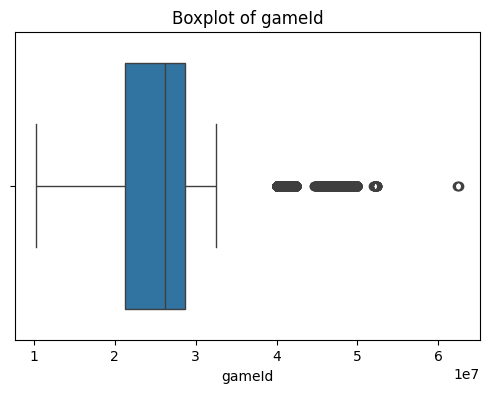

hometeamId


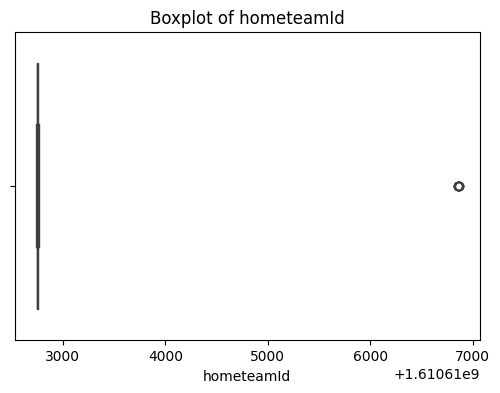

awayteamId


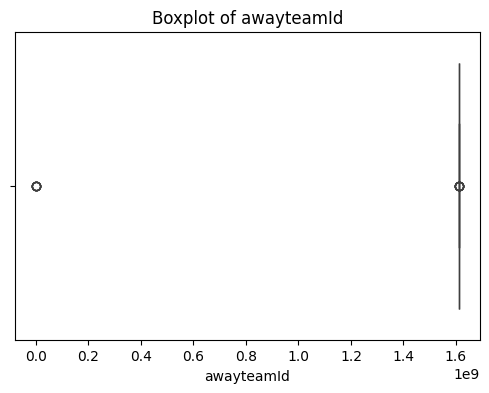

homeScore


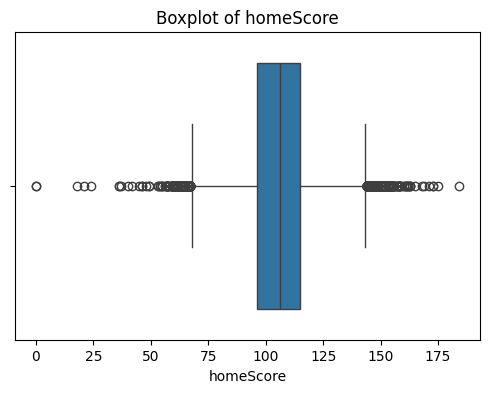

awayScore


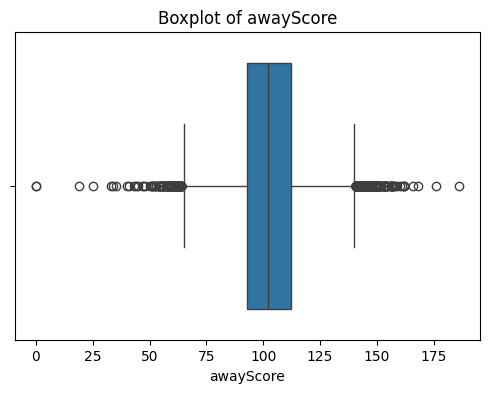

winner


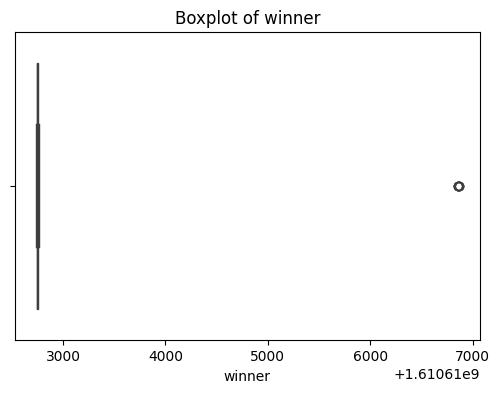

arenaId


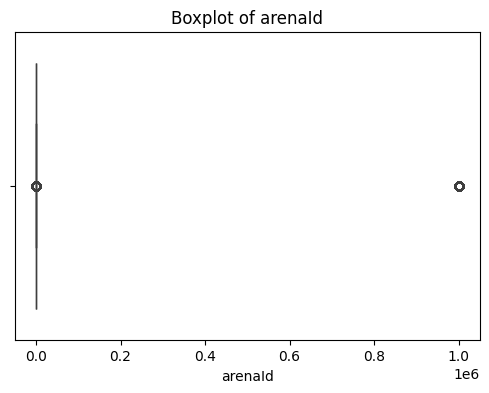

In [69]:
numeric_cols = df_games.select(cs.numeric()).columns


for col in numeric_cols:
    # Boxplot
    print(col)
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_games[col])
    plt.title(f'Boxplot of {col}')
    plt.show()